<a href="https://colab.research.google.com/github/bernardarthur0123-netizen/foundation-/blob/main/02_First_CNN_MNIST_PyTorch_EN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2 · First end-to-end CNN for digit classification (MNIST)

**PyTorch + torchvision**

## Objetivo

Build a complete CNN, train it on MNIST, and analyze every part of the workflow: data loading, architecture, training, evaluation, and interpretation.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
torch.manual_seed(42)

Device: cpu


## 1. Dataset

MNIST contains grayscale `28x28` handwritten digit images. It is ideal for a first CNN because the visual problem is simple, while the training pipeline is already realistic.

In [2]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

len(train_dataset), len(test_dataset)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 723kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.69MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.21MB/s]


(60000, 10000)

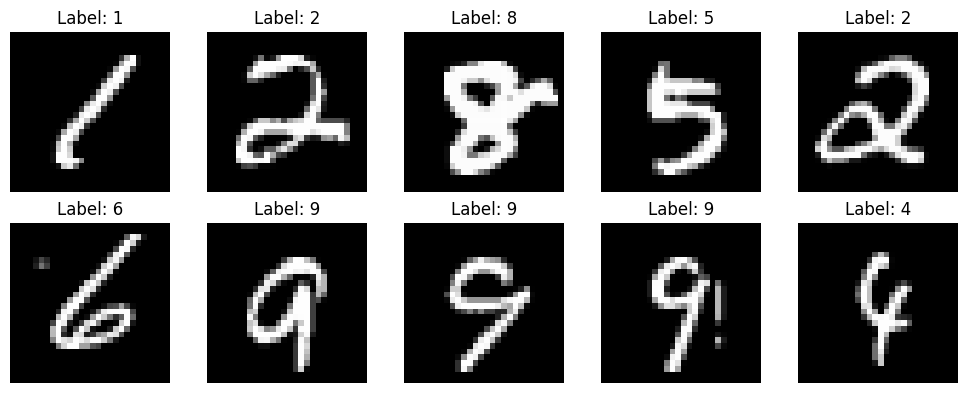

In [3]:

class_names = [str(i) for i in range(10)]

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    img = images[i].squeeze().numpy()
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Arquitectura

The CNN will combine two convolutional blocks followed by a dense classifier. This is enough to introduce depth, feature extraction, and final classification.

In [4]:

class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = MNISTCNN().to(device)
print(model)

MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [5]:

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 206,922
Trainable parameters: 206,922


## 3. Función de pérdida y optimizador

We will use `CrossEntropyLoss`, suitable for multiclass classification, and `Adam`, a widely used optimizer because it offers a good balance between simplicity and performance.

In [6]:

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## 4. Training and evaluation functions

In [10]:

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

## 5. Training

In [11]:

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

epochs = 5

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}")

Epoch 1/5 | train_loss=0.0223 train_acc=0.9929 | test_loss=0.0254 test_acc=0.9923
Epoch 2/5 | train_loss=0.0191 train_acc=0.9939 | test_loss=0.0274 test_acc=0.9912
Epoch 3/5 | train_loss=0.0169 train_acc=0.9941 | test_loss=0.0274 test_acc=0.9911
Epoch 4/5 | train_loss=0.0151 train_acc=0.9948 | test_loss=0.0267 test_acc=0.9919
Epoch 5/5 | train_loss=0.0132 train_acc=0.9957 | test_loss=0.0295 test_acc=0.9911


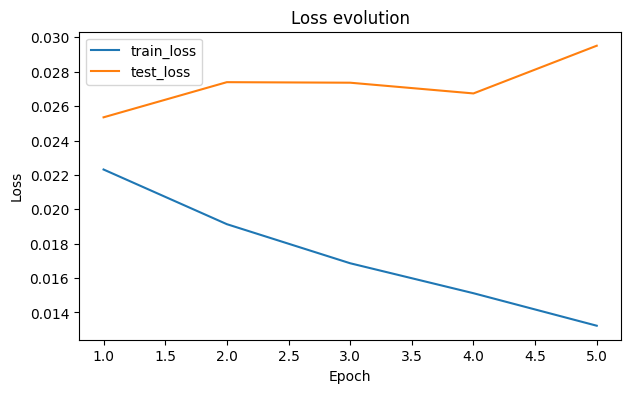

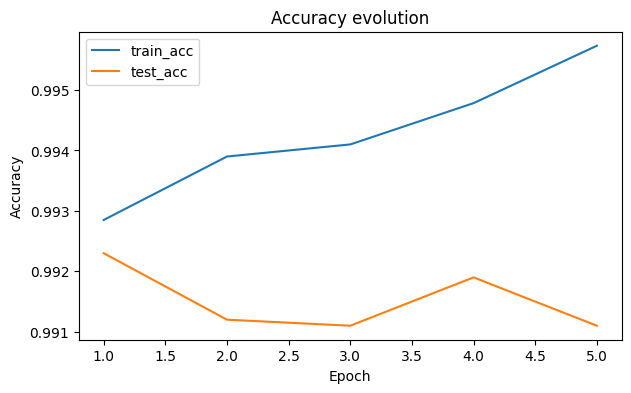

In [12]:

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(7,4))
plt.plot(epochs_range, history["train_loss"], label="train_loss")
plt.plot(epochs_range, history["test_loss"], label="test_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss evolution")
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(epochs_range, history["train_acc"], label="train_acc")
plt.plot(epochs_range, history["test_acc"], label="test_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy evolution")
plt.legend()
plt.show()

## 6. Predicciones y errores

Error analysis is essential in real deep learning work. High accuracy is not enough: we need to understand when the model fails.

In [13]:

@torch.no_grad()
def get_predictions(model, dataloader, device, max_items=25):
    model.eval()
    all_images, all_labels, all_preds = [], [], []

    for images, labels in dataloader:
        outputs = model(images.to(device))
        preds = outputs.argmax(dim=1).cpu()

        all_images.append(images.cpu())
        all_labels.append(labels.cpu())
        all_preds.append(preds)

        if sum(x.size(0) for x in all_images) >= max_items:
            break

    images = torch.cat(all_images)[:max_items]
    labels = torch.cat(all_labels)[:max_items]
    preds = torch.cat(all_preds)[:max_items]
    return images, labels, preds

sample_images, sample_labels, sample_preds = get_predictions(model, test_loader, device)

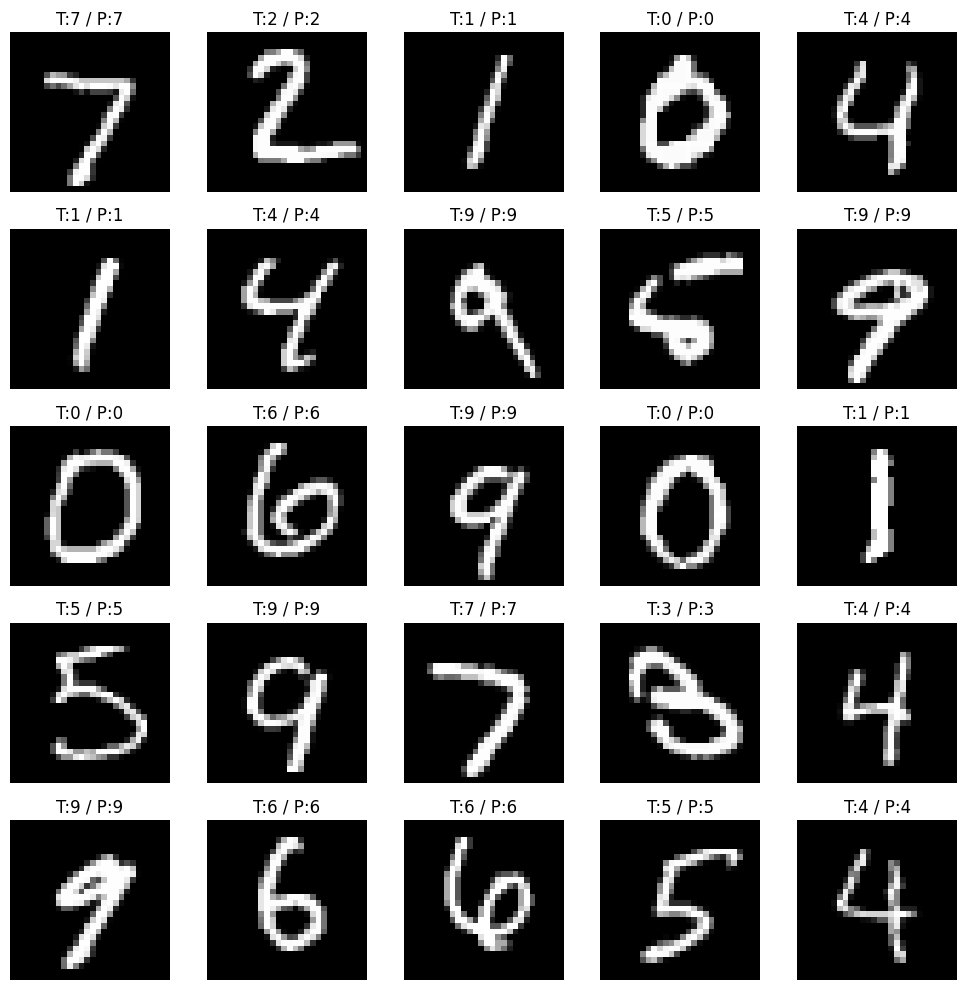

In [14]:

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    img = sample_images[i].squeeze().numpy()
    true_label = sample_labels[i].item()
    pred_label = sample_preds[i].item()
    ax.imshow(img, cmap="gray")
    ax.set_title(f"T:{true_label} / P:{pred_label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Didactic interpretation of the pipeline

1. Convolution detects local patterns.  
2. ReLU introduces non-linearity.  
3. MaxPooling summarizes information and reduces size.  
4. Deeper layers combine simpler patterns.  
5. The final layer produces 10 scores, one per class.  

Then, `CrossEntropyLoss` compares those scores with the real label, and the optimizer adjusts the weights through backpropagation.

---

## 8. Equivalent business example

Imagine a logistics company automatically classifying:
- parcel numbers
- handwritten codes
- scanned labels with irregular quality

MNIST is a simplified version of that problem:  
**recognizing visual symbols from pixels**.

---

## 9. Possible improvements

- use more epochs
- add batch normalization
- use data augmentation
- analyze a confusion matrix
- visualize learned filters

---

## 10. Exercises

1. Replace `Adam` with `SGD` and compare results.  
2. Increase dropout to `0.5`.  
3. Add a third convolution.  
4. Compute per-class accuracy.